In [1]:
import pandas as pd
import numpy as np
import json
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Load results
with open('../data/prophet_results.json') as f:
    prophet_res = json.load(f)
with open('../data/sarima_results.json') as f:
    sarima_res = json.load(f)
with open('../data/lgb_results.json') as f:
    lgb_res = json.load(f)

# Comparison table
comparison = pd.DataFrame([
    {
        'Model': prophet_res['model'],
        'Test MAPE %': prophet_res['test_mape'],
        'Test RMSE': prophet_res['test_rmse'],
        'Test MAE': prophet_res['test_mae'],
        'CV MAPE %': prophet_res['cv_mape_mean'],
        'CV Std': prophet_res['cv_mape_std']
    },
    {
        'Model': sarima_res['model'],
        'Test MAPE %': sarima_res['test_mape'],
        'Test RMSE': sarima_res['test_rmse'],
        'Test MAE': sarima_res['test_mae'],
        'CV MAPE %': '-',
        'CV Std': '-'
    },
    {
        'Model': lgb_res['model'],
        'Test MAPE %': lgb_res['test_mape'],
        'Test RMSE': lgb_res['test_rmse'],
        'Test MAE': lgb_res['test_mae'],
        'CV MAPE %': lgb_res['cv_mape_mean'],
        'CV Std': lgb_res['cv_mape_std']
    }
])

print("Model Comparison - Store 1")
print(comparison.to_string(index=False))

Model Comparison - Store 1
   Model  Test MAPE %  Test RMSE  Test MAE CV MAPE % CV Std
 Prophet        17.16      879.0     708.0     14.04    2.0
  SARIMA        17.95      900.0     755.0         -      -
LightGBM         8.20      453.0     355.0      9.09   2.08


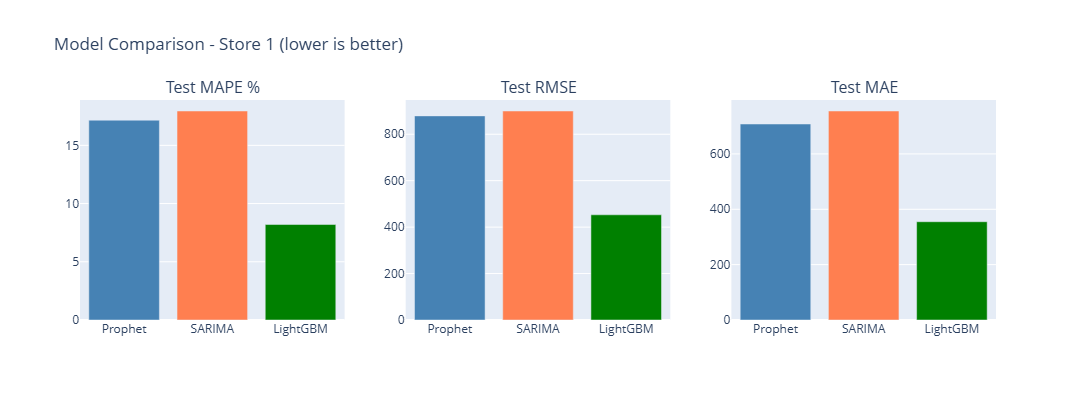

Saved: ../docs/model_comparison.png


In [2]:
# Bar chart comparison
fig = make_subplots(rows=1, cols=3,
                    subplot_titles=['Test MAPE %', 'Test RMSE', 'Test MAE'])

models = comparison['Model'].tolist()
colors = ['steelblue', 'coral', 'green']

fig.add_trace(go.Bar(
    x=models,
    y=comparison['Test MAPE %'].tolist(),
    marker_color=colors,
    showlegend=False
), row=1, col=1)

fig.add_trace(go.Bar(
    x=models,
    y=comparison['Test RMSE'].tolist(),
    marker_color=colors,
    showlegend=False
), row=1, col=2)

fig.add_trace(go.Bar(
    x=models,
    y=comparison['Test MAE'].tolist(),
    marker_color=colors,
    showlegend=False
), row=1, col=3)

fig.update_layout(
    title='Model Comparison - Store 1 (lower is better)',
    height=400
)
fig.show()

import os
os.makedirs("../docs", exist_ok=True)
fig.write_image("../docs/model_comparison.png", width=1200, height=500, scale=2)
print("Saved: ../docs/model_comparison.png")

In [3]:
# Load Store 1 data
df = pd.read_parquet('../data/features.parquet')
store1 = df[df['Store'] == 1].sort_values('Date').copy()

# Rolling stats for anomaly detection
window = 28
store1['rolling_mean'] = store1['Sales'].rolling(window, center=True).mean()
store1['rolling_std'] = store1['Sales'].rolling(window, center=True).std()

store1['upper_bound'] = store1['rolling_mean'] + 2 * store1['rolling_std']
store1['lower_bound'] = store1['rolling_mean'] - 2 * store1['rolling_std']

# Flag anomalies
store1['is_anomaly'] = (
    (store1['Sales'] > store1['upper_bound']) |
    (store1['Sales'] < store1['lower_bound'])
)

anomalies = store1[store1['is_anomaly']].copy()

print(f"Total days: {len(store1)}")
print(f"Anomalies detected: {len(anomalies)} ({len(anomalies)/len(store1)*100:.1f}%)")
print(f"\nAnomaly dates:")
print(anomalies[['Date', 'Sales', 'rolling_mean', 'upper_bound', 'lower_bound']].to_string(index=False))

Total days: 781
Anomalies detected: 14 (1.8%)

Anomaly dates:
      Date  Sales  rolling_mean  upper_bound  lower_bound
2013-02-04   7032   5232.750000  6886.473397  3579.026603
2013-03-04   7675   5348.964286  7209.541694  3488.386878
2013-04-18   2952   4872.642857  6674.985383  3070.300331
2013-05-31   7893   4783.035714  6597.922588  2968.148840
2013-07-29   6290   4516.071429  6250.309221  2781.833636
2013-10-07   6004   4408.142857  6000.241004  2816.044711
2013-12-23   9528   5729.678571  9152.877121  2306.480022
2014-03-03   6198   4616.285714  6109.497005  3123.074424
2014-06-26   2749   4450.857143  6109.642751  2792.071535
2014-09-25   2462   4260.928571  5818.563048  2703.294094
2014-11-01   6532   4569.642857  6044.051034  3095.234681
2014-12-22   9331   5984.428571  9327.095833  2641.761310
2015-02-02   6038   4476.607143  5934.460698  3018.753587
2015-02-10   3136   4551.571429  5802.313481  3300.829376


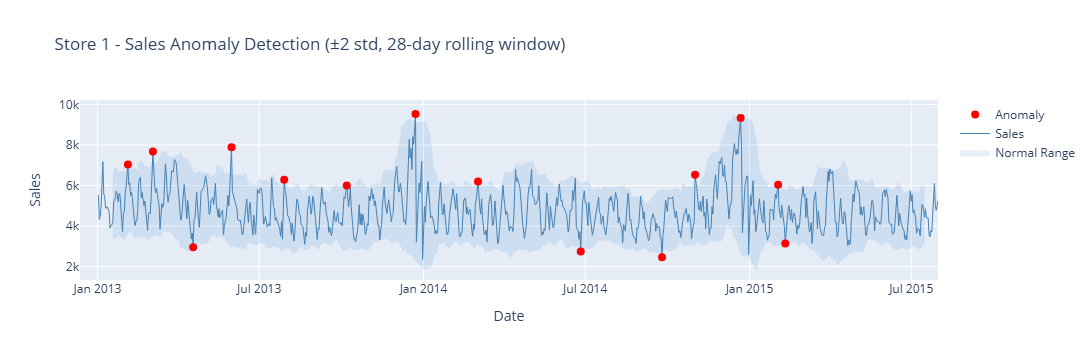

Saved: ../docs/anomalies.png


In [7]:
fig = go.Figure()

# Confidence band
fig.add_trace(go.Scatter(
    x=store1['Date'],
    y=store1['upper_bound'],
    fill=None,
    mode='lines',
    line_color='rgba(0,0,0,0)',
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=store1['Date'],
    y=store1['lower_bound'],
    fill='tonexty',
    mode='lines',
    line_color='rgba(0,0,0,0)',
    fillcolor='rgba(0,100,200,0.1)',
    name='Normal Range'
))

# Sales line
fig.add_trace(go.Scatter(
    x=store1['Date'],
    y=store1['Sales'],
    mode='lines',
    name='Sales',
    line=dict(color='steelblue', width=1)
))

# Anomalies
fig.add_trace(go.Scatter(
    x=anomalies['Date'],
    y=anomalies['Sales'],
    mode='markers',
    name='Anomaly',
    marker=dict(color='red', size=8, symbol='circle')
))

fig.update_layout(
    title='Store 1 - Sales Anomaly Detection (±2 std, 28-day rolling window)',
    xaxis_title='Date',
    yaxis_title='Sales',
    hovermode='x unified'
)
fig.show()

import os
os.makedirs("../docs", exist_ok=True)
fig.write_image("../docs/anomalies.png", width=1200, height=600, scale=2)
print("Saved: ../docs/anomalies.png")

In [5]:
# Analyze anomalies
anomalies_analysis = anomalies[['Date', 'Sales', 'DayOfWeek', 'Promo', 
                                 'IsStateHoliday', 'IsSchoolHoliday', 'Month']].copy()

anomalies_analysis['DayName'] = anomalies_analysis['Date'].dt.day_name()
anomalies_analysis['Type'] = anomalies_analysis['Sales'].apply(
    lambda x: 'High' if x > anomalies_analysis['Sales'].median() else 'Low'
)

print("Anomaly Analysis:")
print(anomalies_analysis[['Date', 'Sales', 'DayName', 'Promo', 
                           'IsStateHoliday', 'IsSchoolHoliday', 'Type']].to_string(index=False))

print(f"\nHigh anomalies: {len(anomalies_analysis[anomalies_analysis['Type']=='High'])}")
print(f"Low anomalies:  {len(anomalies_analysis[anomalies_analysis['Type']=='Low'])}")

print(f"\nAnomaly days of week:")
print(anomalies_analysis['DayName'].value_counts().to_string())

print(f"\nPromo during anomalies:")
print(anomalies_analysis['Promo'].value_counts().to_string())

Anomaly Analysis:
      Date  Sales  DayName  Promo  IsStateHoliday  IsSchoolHoliday Type
2013-02-04   7032   Monday      1               0                0 High
2013-03-04   7675   Monday      1               0                0 High
2013-04-18   2952 Thursday      0               0                0  Low
2013-05-31   7893   Friday      1               0                0 High
2013-07-29   6290   Monday      1               0                1 High
2013-10-07   6004   Monday      1               0                0  Low
2013-12-23   9528   Monday      0               0                1 High
2014-03-03   6198   Monday      1               0                0  Low
2014-06-26   2749 Thursday      0               0                0  Low
2014-09-25   2462 Thursday      0               0                0  Low
2014-11-01   6532 Saturday      0               0                0 High
2014-12-22   9331   Monday      0               0                1 High
2015-02-02   6038   Monday      1             

In [6]:
# Final project summary
print("=" * 55)
print("DEMAND FORECASTING PROJECT - FINAL SUMMARY")
print("=" * 55)
print(f"\nDataset: Rossmann Store Sales")
print(f"Store analyzed: Store 1 (Type C, Assortment A)")
print(f"Train period: 2013-01-02 to 2014-12-31")
print(f"Test period:  2015-01-01 to 2015-07-31")

print(f"\nMODEL RESULTS:")
print(f"{'Model':<12} {'Test MAPE':>10} {'Test RMSE':>10} {'CV MAPE':>10}")
print("-" * 45)
print(f"{'Prophet':<12} {'17.16%':>10} {'879':>10} {'14.04%':>10}")
print(f"{'SARIMA':<12} {'17.95%':>10} {'900':>10} {'N/A':>10}")
print(f"{'LightGBM':<12} {'8.20%':>10} {'453':>10} {'9.09%':>10}")

print(f"\nKEY FINDINGS:")
print(f"1. LightGBM outperforms classical models 2x (MAPE 8% vs 17%)")
print(f"2. Top features: Sales_lag_1, Week, Promo")
print(f"3. Promo increases sales ~37% on average")
print(f"4. December peak: sales 60-80% above baseline")
print(f"5. 14 anomalies detected (1.8%) - 8 on Mondays")
print(f"6. High anomalies correlate with Promo + holiday proximity")

print(f"\nWINNER: LightGBM - best accuracy + uses business features")
print("=" * 55)

DEMAND FORECASTING PROJECT - FINAL SUMMARY

Dataset: Rossmann Store Sales
Store analyzed: Store 1 (Type C, Assortment A)
Train period: 2013-01-02 to 2014-12-31
Test period:  2015-01-01 to 2015-07-31

MODEL RESULTS:
Model         Test MAPE  Test RMSE    CV MAPE
---------------------------------------------
Prophet          17.16%        879     14.04%
SARIMA           17.95%        900        N/A
LightGBM          8.20%        453      9.09%

KEY FINDINGS:
1. LightGBM outperforms classical models 2x (MAPE 8% vs 17%)
2. Top features: Sales_lag_1, Week, Promo
3. Promo increases sales ~37% on average
4. December peak: sales 60-80% above baseline
5. 14 anomalies detected (1.8%) - 8 on Mondays
6. High anomalies correlate with Promo + holiday proximity

WINNER: LightGBM - best accuracy + uses business features
